Person A: Alisha

In [198]:
import random

In [199]:
# ---- Constants: the shape of the whole timetable ----
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri"]      # 5 days
SLOTS = [1, 2, 3, 4, 5, 6]                       # 6 periods per day
# 4 rooms come from Room objects below
# 5 x 6 x 4 = 120 cells total, matching the proposal


# ---- Faculty: who can teach, and exactly when ----
class Faculty:
    def __init__(self, fid, name, availability):
        self.fid = fid
        self.name = name
        # availability: dict like {("Mon", 1): True, ("Mon", 2): False, ...}
        self.availability = availability

    def is_free(self, day, slot):
        return self.availability.get((day, slot), False)


# ---- Room: a physical space, nothing more ----
class Room:
    def __init__(self, rid, name, capacity):
        self.rid = rid
        self.name = name
        self.capacity = capacity


# ---- Session: one class meeting, the atomic unit ----
class Session:
    def __init__(self, sid, dept, faculty_id, class_size, preferred_day=None):
        self.sid = sid
        self.dept = dept
        self.faculty_id = faculty_id
        self.class_size = class_size
        self.preferred_day = preferred_day   # soft preference, not a hard rule

    def pref(self, day, slot):
        # simple preference score: prefers its own day, and earlier slots
        score = 5.0 - 0.5 * (slot - 1)              # earlier slots score higher
        if day == self.preferred_day:
            score += 2.0                              # bonus for the liked day
        return max(score, 0.0)


# ---- Scenario: one full problem instance, bundled ----
class Scenario:
    def __init__(self, sessions, faculty, rooms):
        self.sessions = sessions
        self.faculty = faculty
        self.rooms = rooms

    def sessions_for_dept(self, dept):
        result = []
        for s in self.sessions:
            if s.dept == dept:
                result.append(s)
        return result

    def faculty_by_id(self, fid):
        for f in self.faculty:
            if f.fid == fid:
                return f
        return None

In [200]:
# ---- make_scenario: randomly generates a problem instance for testing ----
"""scale=1 -> 30 sessions (proposal size), 2 -> 60, 3 -> 90.

    Sessions alone cannot scale: 12 faculty cannot teach 90 classes, so the
    run would fail for the wrong reason. Faculty grows with sessions; rooms
    grow at half rate so the grid actually gets tighter.
    """


def make_scenario(n_rooms=4, n_sessions=30, faculty_per_dept=2, seed=0,scale =1.0):
    rng = random.Random(seed)
    n_sessions = int(n_sessions * scale)
    faculty_per_dept = int(np.ceil(faculty_per_dept * scale))
    #n_rooms = int(round(n_rooms * (1 + (scale - 1) * 0.5)))

    depts = ["Computer Science", "Data Science", "Civil", "Mathematics & Science", "Artificial Intelligence", "Mechanical"]
    n_depts = len(depts)

    # faculty: a few per department, each with random per-slot availability
    faculty = []
    dept_faculty = {}
    fid_counter = 1
    for dept in depts:
        dept_faculty[dept] = []
        for _ in range(faculty_per_dept):
            availability = {
                (day, slot): rng.random() < 0.75
                for day in DAYS for slot in SLOTS
            }
            f = Faculty(fid=fid_counter, name=f"Fac{fid_counter}", availability=availability)
            faculty.append(f)
            dept_faculty[dept].append(fid_counter)
            fid_counter += 1

    # rooms: fixed count, varying capacity
    base_caps = [50, 70, 110, 140]
    capacities = [base_caps[i % len(base_caps)] for i in range(n_rooms)]
    rooms = []
    for i in range(n_rooms):
        rooms.append(Room(rid=i + 1, name=f"R{i+1}", capacity=capacities[i]))

    # sessions: round-robin across departments
    sessions = []
    for sid in range(1, n_sessions + 1):
        dept = depts[sid % n_depts]
        faculty_id = rng.choice(dept_faculty[dept])
        class_size = rng.choice([30, 40, 50, 60])
        preferred_day = rng.choice(DAYS)
        sessions.append(Session(sid, dept, faculty_id, class_size, preferred_day))

    return Scenario(sessions=sessions, faculty=faculty, rooms=rooms)

In [201]:
# ---- Grid: the live timetable state and feasibility engine ----
class Grid:
    def __init__(self, scenario):
        self.scenario = scenario
        self.placed = {}            # sid -> (day, slot, room_id)
        self.room_busy = set()      # {(day, slot, room_id)}
        self.faculty_busy = set()   # {(faculty_id, day, slot)}
        self.dept_busy = set()      # {(dept, day, slot)}

    def is_legal(self, session, day, slot, room):
        if session.sid in self.placed:
            return False
        if (day, slot, room.rid) in self.room_busy:
            return False
        if room.capacity < session.class_size:
            return False
        faculty = self.scenario.faculty_by_id(session.faculty_id)
        if not faculty.is_free(day, slot):
            return False
        if (session.faculty_id, day, slot) in self.faculty_busy:
            return False
        if (session.dept, day, slot) in self.dept_busy:
            return False
        return True

    def legal_cells(self, session):
        options = []
        for day in DAYS:
            for slot in SLOTS:
                for room in self.scenario.rooms:
                    if self.is_legal(session, day, slot, room):
                        options.append((day, slot, room.rid))
        return options

    def place(self, session, day, slot, room_id):
        if not self.is_legal(session, day, slot,
                              next(r for r in self.scenario.rooms if r.rid == room_id)):
            return False
        self.placed[session.sid] = (day, slot, room_id)
        self.room_busy.add((day, slot, room_id))
        self.faculty_busy.add((session.faculty_id, day, slot))
        self.dept_busy.add((session.dept, day, slot))
        return True

    def vacate(self, session):
        if session.sid not in self.placed:
            return
        day, slot, room_id = self.placed.pop(session.sid)
        self.room_busy.discard((day, slot, room_id))
        self.faculty_busy.discard((session.faculty_id, day, slot))
        self.dept_busy.discard((session.dept, day, slot))

In [202]:
# ---- validate: an independent auditor, trusts nothing, re-derives everything ----
def validate(grid):
    errors = []
    scenario = grid.scenario
    by_id = {s.sid: s for s in scenario.sessions}
    seen_room = {}
    seen_faculty = {}
    seen_dept = {}

    for sid, (day, slot, room_id) in grid.placed.items():
        s = by_id[sid]
        room = next(r for r in scenario.rooms if r.rid == room_id)

        if room.capacity < s.class_size:
            errors.append(f"Session {sid} too big for {room.name}")

        faculty = scenario.faculty_by_id(s.faculty_id)
        if not faculty.is_free(day, slot):
            errors.append(f"Session {sid} scheduled when faculty unavailable")

        key_room = (day, slot, room_id)
        seen_room.setdefault(key_room, []).append(sid)

        key_fac = (s.faculty_id, day, slot)
        seen_faculty.setdefault(key_fac, []).append(sid)

        key_dept = (s.dept, day, slot)
        seen_dept.setdefault(key_dept, []).append(sid)

    for key, sids in seen_room.items():
        if len(sids) > 1:
            errors.append(f"Room double-booked at {key}: sessions {sids}")
    for key, sids in seen_faculty.items():
        if len(sids) > 1:
            errors.append(f"Faculty double-booked at {key}: sessions {sids}")
    for key, sids in seen_dept.items():
        if len(sids) > 1:
            errors.append(f"Department clash at {key}: sessions {sids}")

    return errors

In [203]:
sc = make_scenario()
grid = Grid(sc)

print("depts:", len({s.dept for s in sc.sessions}))
print("faculty:", len(sc.faculty))
print("rooms:", len(sc.rooms))
print("sessions:", len(sc.sessions))

# try placing the first session into its first legal option
s1 = sc.sessions[0]
options = grid.legal_cells(s1)
print(f"Session {s1.sid} has {len(options)} legal options")
if options:
    day, slot, room_id = options[0]
    success = grid.place(s1, day, slot, room_id)
    print("placed?", success)

print("violations so far:", validate(grid))

depts: 6
faculty: 12
rooms: 4
sessions: 30
Session 1 has 76 legal options
placed? True
violations so far: []


In [204]:
grid2 = Grid(sc)  # fresh grid
placed_count = 0
failed = []

for s in sc.sessions:
    options = grid2.legal_cells(s)
    if options:
        day, slot, room_id = options[0]   # just take the first legal option for now
        grid2.place(s, day, slot, room_id)
        placed_count += 1
    else:
        failed.append(s.sid)

print(f"placed {placed_count}/{len(sc.sessions)}")
print("failed to place:", failed)
print("violations:", validate(grid2))

placed 30/30
failed to place: []
violations: []


Person C

In [205]:
# ============================================================
# PERSON C -- ROOM AGENTS (4 of them, one per room)
# Person A gives us: Grid, Scenario, Session, Room, validate()
# Person B gives us: Bid objects each round
# We decide: when several departments want the same cell, who gets it
# ============================================================

import numpy as np
from collections import defaultdict


class Bid:
    """One department asking one room for one cell, this round.

    Person B creates these. Person C only reads them.
    """

    def __init__(self, dept, session, day, slot, room_id, options_left):
        self.dept = dept                  # "Computer Science"
        self.session = session            # Person A's Session object
        self.day = day                    # "Mon"
        self.slot = slot                  # 1..6
        self.room_id = room_id            # 1..4, which room is being asked
        # how many legal cells this session still has anywhere.
        # low number = this department is nearly stuck = urgent.
        self.options_left = options_left

    def __repr__(self):
        return (f"Bid({self.dept[:4]} s{self.session.sid} "
                f"{self.day}P{self.slot} R{self.room_id})")

In [206]:
class RoomAgent:
    """One room, learning who to grant a contested slot to.

    The decision: when two departments want the same cell, give it to the
    class that FITS this room best, or to the department that is most
    STUCK? A snug fit uses scarce capacity well; rescuing a stuck
    department keeps the whole timetable moving. The agent learns which
    matters more, and when.

    MDP:
      State  = (how contested this cell is, how full my week is)
      Action = which of 3 granting rules to use
      Reward = +1 per slot filled, plus how snugly the class fits,
               minus 0.5 while any session anywhere is unplaced
      Update = Expected SARSA, same rule as the department agents
    """

    RULES = [(1.0, 0.0),      # fit only     -- protect my capacity
             (0.5, 0.5),      # balanced     -- a bit of both
             (0.0, 1.0)]      # urgency only -- rescue whoever is stuck
    RULE_NAMES = ["fit only", "balanced", "urgency only"]

    def __init__(self, room, alpha=0.1, gamma=0.9, seed=0):
        self.room = room
        self.rid = room.rid
        self.name = room.name
        self.capacity = room.capacity

        # Q[state] = 3 values, one per rule. A never-seen state starts at zeros.
        self.Q = defaultdict(lambda: np.zeros(len(self.RULES)))

        self.alpha = alpha        # move 10% toward each new estimate
        self.gamma = gamma        # how much future reward counts
        self.eps = 1.0            # fully random at first, decays later
        self.rng = np.random.default_rng(500 + room.rid + seed)

        self.filled = 0           # slots I filled THIS episode
        self.last = None          # (state, action) of my most recent decision
        self.rule_used = np.zeros(len(self.RULES))
        self.grants = 0
        self.rejects = 0

    # ------------------------------------------------------------------
    def observe(self, n_bids):
        """Compact state: 2 coarse features -> 9 possible states.

        Deliberately tiny. A Q-table needs one row per state, and with a
        handful of states each gets visited thousands of times, so the
        values actually become reliable.
        """
        contested = 0 if n_bids <= 1 else 1 if n_bids <= 3 else 2
        fullness = 0 if self.filled < 8 else 1 if self.filled < 16 else 2
        return (contested, fullness)

    def policy_probs(self, state):
        """Epsilon-greedy probabilities. Expected SARSA needs all three."""
        p = np.full(len(self.RULES), self.eps / len(self.RULES))
        p[int(np.argmax(self.Q[state]))] += 1.0 - self.eps
        return p

    # ------------------------------------------------------------------
    def grant(self, bids):
        """Several departments want the same cell. Pick one winner."""
        state = self.observe(len(bids))

        if self.rng.random() < self.eps:
            a = int(self.rng.integers(len(self.RULES)))    # explore
        else:
            a = int(np.argmax(self.Q[state]))              # exploit
        self.rule_used[a] += 1
        w_fit, w_urg = self.RULES[a]

        def score(b):
            # fit: 55 students in a 60-seat room = 0.92 (snug, good)
            #      55 students in a 140-seat room = 0.39 (wasteful)
            fit = b.session.class_size / self.capacity
            # urgency: 1 option left -> 0.50, 20 options left -> 0.05
            urgency = 1.0 / (1 + b.options_left)
            return w_fit * fit + w_urg * urgency

        winner = max(bids, key=score)
        self.last = (state, a)        # remember, so learn() can credit it
        self.grants += 1
        self.rejects += len(bids) - 1
        return winner

    def note_filled(self):
        self.filled += 1

    # ------------------------------------------------------------------
    def learn(self, reward, next_state, done):
        """EXPECTED SARSA:
             Q(s,a) <- Q(s,a) + alpha [ r + gamma * SUM pi(a'|s') Q(s',a') - Q(s,a) ]

        The SUM is what makes it 'Expected'. Q-learning would use max(),
        assuming the best case next round -- a bad assumption here, since
        the other agents are still learning and changing.
        """
        if self.last is None:
            return                     # I made no decision this round
        state, a = self.last
        if done:
            target = reward
        else:
            probs = self.policy_probs(next_state)
            target = reward + self.gamma * float(np.dot(probs, self.Q[next_state]))
        self.Q[state][a] += self.alpha * (target - self.Q[state][a])
        self.last = None

    def decay(self, frac):
        """frac goes 0 -> 1 across training. Start random, end mostly greedy."""
        self.eps = max(0.05, 1.0 - frac / 0.5)

    def reset_episode(self):
        self.filled = 0
        self.last = None

    def report(self):
        lines = [f"{self.name} (cap {self.capacity}) | granted {self.grants}, "
                 f"rejected {self.rejects} | {len(self.Q)} states"]
        for st in sorted(self.Q):
            c = ["1 bid", "2-3 bids", "4+ bids"][st[0]]
            f = ["empty", "half full", "nearly full"][st[1]]
            q = self.Q[st]
            lines.append(f"    {c:9} + {f:12} -> "
                         f"{self.RULE_NAMES[int(np.argmax(q))]:13}  Q={np.round(q, 2)}")
        return "\n".join(lines)


def make_room_agents(scenario, seed=0):
    """One agent per room, keyed by room id so resolve_round can find them."""
    return {r.rid: RoomAgent(r, seed=seed) for r in scenario.rooms}


def resolve_round(bids, room_agents, grid, reward_cfg=None):
    """Resolve one negotiation round.

    Person B's loop calls this with all the bids the department agents
    produced. We group them by cell, let each room agent grant one, place
    the winner, and hand back rewards for both sides.

    IMPORTANT: 'placed' and 'rejected' contain the SAME Bid objects that
    came in, because Person B checks identity (`b is self.last_bid`) to
    work out whether its bid won or lost.
    """
    cfg = reward_cfg or {"placed": 10.0,   # dept reward for a placement
                         "pref": 8.0,      # multiplies the 0-5 preference score was 3.0
                         "clash": -20.0,   # dept penalty for losing a clash
                         "fill": 1.0}      # room reward for filling a slot

    # group by the exact cell wanted -- two bids on one cell is a clash
    by_cell = defaultdict(list)
    for b in bids:
        by_cell[(b.day, b.slot, b.room_id)].append(b)

    dept_rewards = defaultdict(float)
    room_rewards = defaultdict(float)
    placed, rejected = [], []

    for (day, slot, rid), group in by_cell.items():
        agent = room_agents[rid]

        # A room only makes a DECISION when bids compete. With one bid there
        # is nothing to choose, so no Q-value is credited -- otherwise the
        # table fills with fake "decisions" the room never actually made.
        if len(group) == 1:
            winner = group[0]
            agent.grants += 1
        else:
            winner = agent.grant(group)

        # Person A's place() re-checks legality, so this can never go wrong
        if grid.place(winner.session, day, slot, rid):
            agent.note_filled()
            placed.append(winner)
            dept_rewards[winner.dept] += (cfg["placed"]
                + cfg["pref"] * winner.session.pref(day, slot))
            room_rewards[rid] += (cfg["fill"]
                + winner.session.class_size / agent.capacity)

        for b in group:
            if b is not winner:
                dept_rewards[b.dept] += cfg["clash"]
                rejected.append(b)

    return {"placed": placed, "rejected": rejected,
            "dept_rewards": dept_rewards, "room_rewards": room_rewards}

Person B- Snigdha

In [207]:

import numpy as np
from collections import defaultdict

# ---- the 5 actions from the proposal slide ----
PROPOSE, ACCEPT, REJECT, COUNTER, SWAP = range(5)
ACTION_NAMES = ["propose", "accept", "reject", "counter", "swap"]


class RoundView:
    """A snapshot of the board, built ONCE per round and shared by all depts.

    legal_cells() is the slow call (30 sessions x 120 cells), so we compute it
    once here instead of once per department per feature.
    """

    def __init__(self, grid):
        self.grid = grid
        self.options = {}                       # sid -> list of legal (day, slot, rid)
        crowd = defaultdict(int)                # (day, slot) -> how many sessions could go there
        for s in grid.scenario.sessions:
            if s.sid in grid.placed:
                continue
            cells = grid.legal_cells(s)
            self.options[s.sid] = cells
            for (d, sl, _) in cells:
                crowd[(d, sl)] += 1
        m = max(crowd.values(), default=0)
        # normalised 0..5, public info: reveals nobody's private preference
        self.crowd = {k: 5.0 * v / m for k, v in crowd.items()} if m else {}

    def crowd_at(self, day, slot):
        return self.crowd.get((day, slot), 0.0)


class DeptAgent:
    """One department, learning WHICH NEGOTIATION MOVE suits which situation.

    MDP:
      State  = (sessions left, how boxed-in my worst session is,
                best preference on offer, what happened to my last bid)
               -> 4 x 3 x 3 x 3 = 108 states
      Action = propose / accept / reject / counter / swap
      Reward = comes from Person C's resolve_round (placed / preference /
               clash penalty) plus time pressure and any swap gain
      Update = Expected SARSA

    Safety: every bid is chosen ONLY from grid.legal_cells(), so an invalid
    placement can never be proposed.
    """

    def __init__(self, dept, alpha=0.1, gamma=0.9, seed=0):
        self.dept = dept
        self.Q = defaultdict(lambda: np.zeros(len(ACTION_NAMES)))
        self.alpha, self.gamma = alpha, gamma
        self.eps = 1.0
        self.rng = np.random.default_rng(seed)

        self.last = None             # (state, action_actually_executed)
        self.last_outcome = 0        # 0 = nothing yet, 1 = won last bid, 2 = lost it
        self.last_bid = None         # the Bid I made last round
        self.bonus = 0.0             # extra reward earned by a swap this round
        self.used = np.zeros(len(ACTION_NAMES))   # stats for the report
        self.swaps_done = 0

    # ---------------------------------------------------------------
    def my_left(self, view):
        """My unplaced sessions that still have at least one legal cell."""
        by = view.grid.scenario.sessions_for_dept(self.dept)
        return [s for s in by if s.sid in view.options]

    def observe(self, view):
        """Compressed state. NOT the raw grid -- 4 coarse features, 108 states."""
        mine = self.my_left(view)
        n = len(mine)
        a = 0 if n <= 1 else 1 if n == 2 else 2 if n <= 4 else 3

        tightest = min((len(view.options[s.sid]) for s in mine), default=99)
        b = 0 if tightest <= 3 else 1 if tightest <= 15 else 2

        best = max((s.pref(d, sl) for s in mine for (d, sl, _) in view.options[s.sid]),
                   default=0.0)
        c = 0 if best < 3.0 else 1 if best < 5.0 else 2

        return (a, b, c, self.last_outcome)

    # ---------------------------------------------------------------
    def policy_probs(self, state):
        """Epsilon-greedy probabilities. Expected SARSA needs all five numbers."""
        p = np.full(len(ACTION_NAMES), self.eps / len(ACTION_NAMES))
        p[int(np.argmax(self.Q[state]))] += 1.0 - self.eps
        return p

    def choose(self, state):
        if self.rng.random() < self.eps:
            return int(self.rng.integers(len(ACTION_NAMES)))
        return int(np.argmax(self.Q[state]))

    # ---------------------------------------------------------------
    def _make_bid(self, s, cell, view):
        d, sl, rid = cell
        return Bid(self.dept, s, d, sl, rid, len(view.options[s.sid]))

    def _propose(self, mine, view):
        """Assertive: the single best-preference cell across all my sessions."""
        best, pick = -1e9, None
        for s in mine:
            for c in view.options[s.sid]:
                v = s.pref(c[0], c[1])
                if v > best:
                    best, pick = v, (s, c)
        return self._make_bid(pick[0], pick[1], view)

    def _accept(self, mine, view):
        """Settle: rescue my most boxed-in session in the cell fewest others want."""
        s = min(mine, key=lambda x: len(view.options[x.sid]))
        c = min(view.options[s.sid],
                key=lambda c: (view.crowd_at(c[0], c[1]) - 0.3 * s.pref(c[0], c[1])))
        return self._make_bid(s, c, view)

    def _counter(self, mine, view):
        """After losing a clash: same session, a DIFFERENT (slot) that is still good.
        Returns None if there is no lost bid to counter."""
        if self.last_bid is None or self.last_outcome != 2:
            return None
        s = self.last_bid.session
        if s.sid not in view.options:
            return None
        lost = (self.last_bid.day, self.last_bid.slot)
        alts = [c for c in view.options[s.sid] if (c[0], c[1]) != lost]
        if not alts:
            return None
        c = max(alts, key=lambda c: s.pref(c[0], c[1]) - 0.5 * view.crowd_at(c[0], c[1]))
        return self._make_bid(s, c, view)

    def _swap(self, view):
        """Move ALREADY-placed session to a better cell (uses Person A's vacate()).
        Done immediately on the grid; returns True if a better cell was found."""
        grid = view.grid
        by_id = {s.sid: s for s in grid.scenario.sessions}
        mine_placed = [by_id[sid] for sid in grid.placed if by_id[sid].dept == self.dept]
        if not mine_placed:
            return False
        s = mine_placed[int(self.rng.integers(len(mine_placed)))]
        old = grid.placed[s.sid]
        old_pref = s.pref(old[0], old[1])

        grid.vacate(s)                                     # free my own cell first
        cells = grid.legal_cells(s)                        # now re-ask what is legal
        best = max(cells, key=lambda c: s.pref(c[0], c[1]), default=None)
        if best is not None and s.pref(best[0], best[1]) > old_pref + 0.25:
            grid.place(s, *best)
            self.bonus += 3.0 * (s.pref(best[0], best[1]) - old_pref)
            self.swaps_done += 1
            return True
        grid.place(s, *old)                                # no gain -> put it back
        return False

    # ---------------------------------------------------------------
    def act(self, view):
        """Pick a move for this round. Returns (state, action_executed, bid_or_None).

        If the chosen move is impossible right now (e.g. 'counter' with no lost
        bid), it degrades to 'propose' and we credit the move that really ran.
        """
        state = self.observe(view)
        a = self.choose(state)
        mine = self.my_left(view)
        bid = None

        if a == SWAP and not self._swap(view):
            a = PROPOSE                                    # nothing to swap
        elif a == COUNTER:
            bid = self._counter(mine, view)
            if bid is None:
                a = PROPOSE
        elif a == REJECT:
            pass                                           # walk away this round

        if a == PROPOSE and mine:
            bid = self._propose(mine, view)
        elif a == ACCEPT and mine:
            bid = self._accept(mine, view)
        elif a == SWAP:
            pass                                           # the swap itself was the move

        self.used[a] += 1
        self.last = (state, a)
        self.last_bid = bid
        return state, a, bid

    # ---------------------------------------------------------------
    def record_result(self, out):
        """Look at Person C's resolve_round() output: did my bid win or lose?"""
        if self.last_bid is None:
            self.last_outcome = 0
        elif any(b is self.last_bid for b in out["placed"]):
            self.last_outcome = 1
        elif any(b is self.last_bid for b in out["rejected"]):
            self.last_outcome = 2
        else:
            self.last_outcome = 0

    def learn(self, reward, next_state, done):
        """EXPECTED SARSA:
             Q(s,a) <- Q(s,a) + alpha [ r + gamma * SUM pi(a'|s') Q(s',a') - Q(s,a) ]
        """
        if self.last is None:
            return
        state, a = self.last
        reward += self.bonus                                # swap gain, if any
        self.bonus = 0.0
        if done:
            target = reward
        else:
            target = reward + self.gamma * float(
                np.dot(self.policy_probs(next_state), self.Q[next_state]))
        self.Q[state][a] += self.alpha * (target - self.Q[state][a])
        self.last = None

    def decay(self, frac):
        self.eps = max(0.05, 1.0 - frac / 0.5)

    def reset_episode(self):
        self.last, self.last_bid, self.last_outcome, self.bonus = None, None, 0, 0.0

    def report(self):
        top = int(np.argmax(self.used))
        return (f"{self.dept:24} | {len(self.Q):3d} states | most used: "
                f"{ACTION_NAMES[top]:8} | swaps {self.swaps_done}")


def make_dept_agents(scenario, seed=0):
    depts = sorted({s.dept for s in scenario.sessions})
    return {d: DeptAgent(d, seed=seed + i) for i, d in enumerate(depts)}

'''
# ============ TEST RUN (stand-in for Person D) ============
# ---- stand-in for Person D: full episode loop using A + B + C together ----
import time
def run_episode(sc, grid, dept_agents, room_agents, max_rounds=60, learn=True):
    for a in list(dept_agents.values()) + list(room_agents.values()):
        a.reset_episode()
    for rnd in range(max_rounds):
        view = RoundView(grid)
        states, bids = {}, []
        for d, ag in dept_agents.items():
            st, a, bid = ag.act(view)
            states[d] = st
            if bid: bids.append(bid)
        out = resolve_round(bids, room_agents, grid) if bids else \
              {"placed": [], "rejected": [], "dept_rewards": {}, "room_rewards": {}}
        done = len(grid.placed) == len(sc.sessions)
        nview = RoundView(grid)
        for d, ag in dept_agents.items():
            ag.record_result(out)
            r = out["dept_rewards"].get(d, 0.0) - 1.0 - (0.5 if not done else 0.0)
            if learn: ag.learn(r, ag.observe(nview), done)
        for rid, ra in room_agents.items():
            r = out["room_rewards"].get(rid, 0.0) - (0.5 if not done else 0.0)
            if learn: ra.learn(r, ra.observe(2), done)
        if done: break
    return len(grid.placed), rnd + 1

sc = make_scenario(seed=0)
dagents, ragents = make_dept_agents(sc), make_room_agents(sc)
EP = 200        # training episodes; try 400 for the final run
t=time.time(); hist=[]
for ep in range(EP):
    for a in list(dagents.values())+list(ragents.values()): a.decay(ep/EP)
    grid = Grid(sc)
    hist.append(run_episode(sc, grid, dagents, ragents))
    if (ep+1) % (EP//5)==0:
        h=hist[-EP//5:]
        print(f"ep {ep+1:4d} placed {np.mean([x[0] for x in h]):.1f}/30 rounds {np.mean([x[1] for x in h]):.1f}  {time.time()-t:.0f}s")
for a in list(dagents.values())+list(ragents.values()): a.eps=0.02
grid=Grid(sc); n,r=run_episode(sc,grid,dagents,ragents,learn=False)
print("FINAL placed",n,"/30 rounds",r,"| validate:",validate(grid))
for a in dagents.values(): print(a.report())
tot=sum(a.used.sum() for a in dagents.values())
for i,nm in enumerate(ACTION_NAMES): print(f"  {nm:8}{sum(a.used[i] for a in dagents.values())/tot:.1%}")'''


'\n# ============ TEST RUN (stand-in for Person D) ============\n# ---- stand-in for Person D: full episode loop using A + B + C together ----\nimport time\ndef run_episode(sc, grid, dept_agents, room_agents, max_rounds=60, learn=True):\n    for a in list(dept_agents.values()) + list(room_agents.values()):\n        a.reset_episode()\n    for rnd in range(max_rounds):\n        view = RoundView(grid)\n        states, bids = {}, []\n        for d, ag in dept_agents.items():\n            st, a, bid = ag.act(view)\n            states[d] = st\n            if bid: bids.append(bid)\n        out = resolve_round(bids, room_agents, grid) if bids else               {"placed": [], "rejected": [], "dept_rewards": {}, "room_rewards": {}}\n        done = len(grid.placed) == len(sc.sessions)\n        nview = RoundView(grid)\n        for d, ag in dept_agents.items():\n            ag.record_result(out)\n            r = out["dept_rewards"].get(d, 0.0) - 1.0 - (0.5 if not done else 0.0)\n            if lea

Person C- Sanaz

In [208]:
# ---- what the room agents learned (run after Person B's training cell) ----
print("--- what each room learned ---")
for a in es["rooms"].values():
    print(a.report())

tot = sum(a.rule_used.sum() for a in es["rooms"].values())
print("\nroom rule usage across all rooms:")
for i, n in enumerate(RoomAgent.RULE_NAMES):
    print(f"  {n:13} {sum(a.rule_used[i] for a in es['rooms'].values()) / tot:.1%}")

--- what each room learned ---
R1 (cap 50) | granted 6558, rejected 512 | 4 states
    2-3 bids  + empty        -> balanced       Q=[ 9.48 18.53  8.99]
    2-3 bids  + half full    -> balanced       Q=[ 4.94 19.7   5.02]
    2-3 bids  + nearly full  -> balanced       Q=[3.94 9.08 1.16]
    4+ bids   + half full    -> fit only       Q=[6.02 0.   0.  ]
R2 (cap 70) | granted 5547, rejected 792 | 5 states
    2-3 bids  + empty        -> urgency only   Q=[15.33  9.31 20.47]
    2-3 bids  + half full    -> balanced       Q=[ 6.73 13.47  6.81]
    2-3 bids  + nearly full  -> fit only       Q=[2.34 0.12 0.3 ]
    4+ bids   + empty        -> urgency only   Q=[0.   0.   0.45]
    4+ bids   + half full    -> fit only       Q=[1.21 0.   0.15]
R3 (cap 110) | granted 4039, rejected 1051 | 3 states
    2-3 bids  + empty        -> fit only       Q=[10.19  7.86  8.86]
    2-3 bids  + half full    -> fit only       Q=[9.55 4.33 4.15]
    4+ bids   + empty        -> fit only       Q=[1.05 0.   0.  ]
R4 (

In [209]:
# ============================================================
# PERSON D -- TRAINING LOOP, Q-LEARNING ARM, METRICS, PLOTS
# Uses: A (Grid, make_scenario, validate)
#       B (DeptAgent, RoundView, make_dept_agents)
#       C (RoomAgent, make_room_agents, resolve_round)
# ============================================================
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


def q_learning_update(agent, reward, next_state, done):
    """Same agent, ONE line different from Expected SARSA.

        Expected SARSA : target = r + gamma * SUM pi(a'|s') Q(s',a')
        Q-learning     : target = r + gamma * MAX Q(s',a')

    Q-learning assumes the best case next round. Here nine other agents are
    still learning and competing, so the slot it counts on may be taken.
    That is the on-policy argument, and this arm tests it.
    """
    if agent.last is None:
        return
    state, a = agent.last
    reward += getattr(agent, "bonus", 0.0)
    agent.bonus = 0.0
    target = reward if done else reward + agent.gamma * float(np.max(agent.Q[next_state]))
    agent.Q[state][a] += agent.alpha * (target - agent.Q[state][a])
    agent.last = None


def run_episode(sc, grid, dept_agents, room_agents, max_rounds=60,
                learn=True, algo="expected_sarsa", stats=None):
    """One full attempt at a timetable.

    All departments bid SIMULTANEOUSLY, rooms arbitrate, everyone learns.
    The joint action is what makes this a Markov Game, not N separate MDPs.
    """
    for a in list(dept_agents.values()) + list(room_agents.values()):
        a.reset_episode()

    ep_dept_reward, ep_room_reward = defaultdict(float), defaultdict(float)
    clashes = offers = accepted = 0

    for rnd in range(max_rounds):
        view = RoundView(grid)

        # --- 1. departments propose
        bids = []
        for d, ag in dept_agents.items():
            st, a, bid = ag.act(view)
            if bid:
                bids.append(bid)

        # --- 2. rooms grant / reject  (Person C)
        out = (resolve_round(bids, room_agents, grid) if bids else
               {"placed": [], "rejected": [], "dept_rewards": {}, "room_rewards": {}})
        offers += len(bids)
        accepted += len(out["placed"])
        clashes += len(out["rejected"])

        done = len(grid.placed) == len(sc.sessions)
        nview = RoundView(grid)

        # --- 3. everyone learns from their own reward
        for d, ag in dept_agents.items():
            ag.record_result(out)
            r = out["dept_rewards"].get(d, 0.0) - 0.3 - (0.2 if not done else 0.0)
            ep_dept_reward[d] += r
            if learn:
                if algo == "q_learning":
                    q_learning_update(ag, r, ag.observe(nview), done)
                else:
                    ag.learn(r, ag.observe(nview), done)
            else:
                ag.last = None

        for rid, ra in room_agents.items():
            r = out["room_rewards"].get(rid, 0.0) - (0.5 if not done else 0.0)
            ep_room_reward[rid] += r
            if learn:
                ra.learn(r, ra.observe(2), done)
            else:
                ra.last = None

        if done:
            break

    m = metrics(sc, grid, rnd + 1, ep_dept_reward, ep_room_reward,
                clashes, offers, accepted)
    if stats is not None:
        stats.append(m)
    return m

In [210]:
def metrics(sc, grid, rounds, dept_reward, room_reward, clashes, offers, accepted):
    """Every number slide 8 promised, computed in one place."""
    placed, total = len(grid.placed), len(sc.sessions)

    by_id = {s.sid: s for s in sc.sessions}
    per_dept, counts, tot_pref = defaultdict(float), defaultdict(int), 0.0
    for sid, (day, slot, rid) in grid.placed.items():
        p = by_id[sid].pref(day, slot)
        tot_pref += p
        per_dept[by_id[sid].dept] += p
        counts[by_id[sid].dept] += 1
    dept_means = [per_dept[d] / counts[d] for d in counts] or [0.0]

    cells = len(DAYS) * len(SLOTS) * len(sc.rooms)
    return {
        "placed": placed,
        "success": float(placed == total),              # all sessions placed
        "avg_reward": float(np.mean(list(dept_reward.values()) or [0])),
        "room_reward": float(np.mean(list(room_reward.values()) or [0])),
        "rounds": rounds,                               # convergence speed
        "preference": tot_pref / max(placed, 1),
        "utilisation": placed / cells,                  # room utilisation
        "clashes": clashes,                             # clashes remaining
        "acceptance": accepted / max(offers, 1),        # cooperation level
        "fairness_min": float(np.min(dept_means)),      # worst-off department
        "fairness_gap": float(np.max(dept_means) - np.min(dept_means)),
        "violations": len(validate(grid)),              # must always be 0
    }


def train(sc, episodes=300, seed=0, algo="expected_sarsa", verbose=True):
    dept_agents = make_dept_agents(sc, seed=seed)
    room_agents = make_room_agents(sc, seed=seed)
    history, t0 = [], time.time()

    for ep in range(episodes):
        for a in list(dept_agents.values()) + list(room_agents.values()):
            a.decay(ep / episodes)             # explore early, exploit late
        grid = Grid(sc)
        run_episode(sc, grid, dept_agents, room_agents, algo=algo, stats=history)

        if verbose and (ep + 1) % max(1, episodes // 5) == 0:
            w = history[-max(1, episodes // 5):]
            print(f"  ep {ep+1:4d} | reward {np.mean([h['avg_reward'] for h in w]):7.1f}"
                  f" | placed {np.mean([h['placed'] for h in w]):5.1f}/{len(sc.sessions)}"
                  f" | success {np.mean([h['success'] for h in w]):.2f}"
                  f" | pref {np.mean([h['preference'] for h in w]):.2f}"
                  f" | rounds {np.mean([h['rounds'] for h in w]):4.1f}")
    if verbose:
        print(f"  trained in {time.time()-t0:.0f}s")
    return {"dept": dept_agents, "rooms": room_agents,
            "history": history, "sc": sc, "algo": algo}


def evaluate(sc, trained, n=20, eps=0.02):
    """Exploration nearly off. A tiny eps stays on purpose: with a fully
    deterministic policy two agents can lock onto the same cell forever."""
    for a in list(trained["dept"].values()) + list(trained["rooms"].values()):
        a.eps = eps
    runs = []
    for _ in range(n):
        grid = Grid(sc)
        runs.append(run_episode(sc, grid, trained["dept"], trained["rooms"], learn=False))
    return {k: float(np.mean([r[k] for r in runs])) for k in runs[0]}


def run_baseline(sc, how="greedy_pref", seed=0, max_rounds=60):
    """No learning. The bar the agents must clear."""
    rng = np.random.default_rng(seed)
    grid = Grid(sc)
    depts = sorted({s.dept for s in sc.sessions})
    clashes = offers = accepted = 0
    room_agents = make_room_agents(sc, seed=seed)
    for a in room_agents.values():
        a.eps = 0.0

    for rnd in range(max_rounds):
        view = RoundView(grid)
        bids = []
        for d in depts:
            mine = [s for s in sc.sessions_for_dept(d)
                    if s.sid in view.options and view.options[s.sid]]
            if not mine:
                continue
            if how == "random":
                s = mine[rng.integers(len(mine))]
                cells = view.options[s.sid]
                c = cells[rng.integers(len(cells))]
            elif how == "greedy":                       # first legal cell
                s = mine[0]
                c = sorted(view.options[s.sid])[0]
            else:                                       # greedy on preference
                s, c, best = None, None, -1e9
                for x in mine:
                    for cell in view.options[x.sid]:
                        v = x.pref(cell[0], cell[1])
                        if v > best:
                            s, c, best = x, cell, v
            bids.append(Bid(d, s, c[0], c[1], c[2], len(view.options[s.sid])))

        if not bids:
            break
        out = resolve_round(bids, room_agents, grid)
        offers += len(bids)
        accepted += len(out["placed"])
        clashes += len(out["rejected"])
        if len(grid.placed) == len(sc.sessions):
            break

    return metrics(sc, grid, rnd + 1, {}, {}, clashes, offers, accepted)

In [211]:
def smooth(x, k=25):
    x = np.asarray(x, dtype=float)
    return np.convolve(x, np.ones(k) / k, mode="valid") if len(x) >= k else x


def plot_curves(es, ql=None):
    panels = [("avg_reward", "Average reward per department"),
              ("success",    "Success rate (all sessions placed)"),
              ("preference", "Preference satisfaction"),
              ("rounds",     "Rounds to finish (convergence speed)"),
              ("clashes",    "Clashes per episode"),
              ("acceptance", "Cooperation (offers accepted)")]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for (key, title), ax in zip(panels, axes.ravel()):
        ax.plot(smooth([h[key] for h in es["history"]]), label="Expected SARSA", lw=1.8)
        if ql:
            ax.plot(smooth([h[key] for h in ql["history"]]), label="Q-Learning",
                    lw=1.8, alpha=0.75)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("episode")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=150)
    plt.show()


def emergent_report(es):
    """Evidence for the three behaviours the proposal promised."""
    h = es["history"]
    n = len(h)
    early, late = h[:n // 10], h[-n // 10:]

    print("=" * 62)
    print("EMERGENT BEHAVIOUR")
    print("=" * 62)
    print(f"{'':22}{'first 10%':>12}{'last 10%':>12}")
    for k, label in [("rounds", "rounds to finish"), ("clashes", "clashes"),
                     ("acceptance", "offers accepted"), ("preference", "preference"),
                     ("success", "success rate")]:
        print(f"  {label:20}{np.mean([x[k] for x in early]):>12.2f}"
              f"{np.mean([x[k] for x in late]):>12.2f}")

    print("\n1. DEADLOCKS BREAKING AS EXPLORATION DECAYS")
    print(f"   rounds needed fell {np.mean([x['rounds'] for x in early]):.1f}"
          f" -> {np.mean([x['rounds'] for x in late]):.1f}")

    print("\n2. GIVING UP WEAK SLOTS EARLY (department action mix)")
    tot = sum(a.used.sum() for a in es["dept"].values())
    for i, nm in enumerate(ACTION_NAMES):
        print(f"   {nm:9} {sum(a.used[i] for a in es['dept'].values()) / tot:6.1%}")

    print("\n3. DEPARTMENTS TRADING SLOTS")
    for a in es["dept"].values():
        print(f"   {a.dept:24} swaps {a.swaps_done}")

    print("\n4. ROOM AGENT ROLE SPLIT")
    for a in es["rooms"].values():
        if a.Q:
            top = max(a.Q, key=lambda s: np.max(a.Q[s]))
            print(f"   {a.name} (cap {a.capacity:3}) -> "
                  f"{a.RULE_NAMES[int(np.argmax(a.Q[top]))]}")


def comparison_table(rows):
    keys = ["placed", "success", "preference", "fairness_min", "rounds",
            "clashes", "utilisation", "acceptance", "violations"]
    print(f"{'method':18}" + "".join(f"{k[:9]:>11}" for k in keys))
    print("-" * (18 + 11 * len(keys)))
    for name, m in rows:
        print(f"{name:18}" + "".join(f"{m[k]:>11.2f}" for k in keys))

60 sessions | 4 rooms | 24 faculty

=== Expected SARSA ===
  ep   60 | reward   534.7 | placed  60.0/60 | success 1.00 | pref 6.06 | rounds 18.1
  ep  120 | reward   527.9 | placed  60.0/60 | success 1.00 | pref 6.00 | rounds 16.4
  ep  180 | reward   534.6 | placed  60.0/60 | success 1.00 | pref 6.00 | rounds 14.8
  ep  240 | reward   534.6 | placed  60.0/60 | success 1.00 | pref 6.00 | rounds 14.6
  ep  300 | reward   536.4 | placed  60.0/60 | success 1.00 | pref 6.00 | rounds 14.3
  trained in 52s

=== Q-Learning (comparison arm) ===
  ep   60 | reward   537.2 | placed  60.0/60 | success 1.00 | pref 6.06 | rounds 17.9
  ep  120 | reward   540.8 | placed  60.0/60 | success 1.00 | pref 6.10 | rounds 16.1
  ep  180 | reward   538.9 | placed  60.0/60 | success 1.00 | pref 6.01 | rounds 14.9
  ep  240 | reward   539.1 | placed  60.0/60 | success 1.00 | pref 6.03 | rounds 14.8
  ep  300 | reward   551.0 | placed  60.0/60 | success 1.00 | pref 6.09 | rounds 14.3
  trained in 52s

=== Evalu

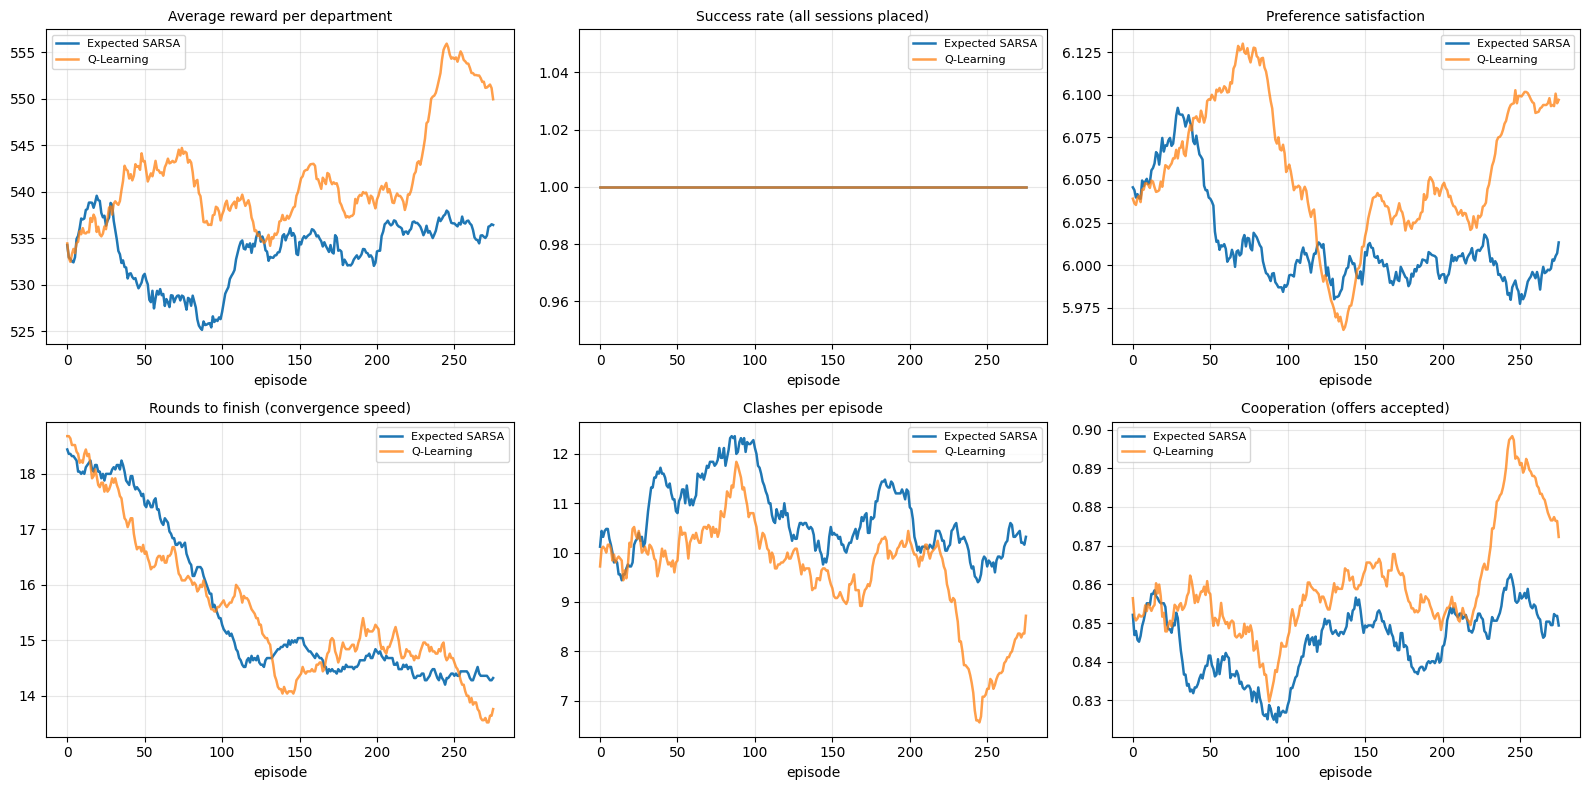

In [212]:
EPISODES = 300

sc = make_scenario(scale=2)     # 60 sessions, 6 rooms, 24 faculty
print(f"{len(sc.sessions)} sessions | {len(sc.rooms)} rooms | {len(sc.faculty)} faculty\n")

print("=== Expected SARSA ===")
es = train(sc, episodes=EPISODES, seed=0, algo="expected_sarsa")

print("\n=== Q-Learning (comparison arm) ===")
ql = train(sc, episodes=EPISODES, seed=0, algo="q_learning")

print("\n=== Evaluation ===")
rows = [("random", run_baseline(sc, "random")),
        ("greedy", run_baseline(sc, "greedy")),
        ("greedy_pref", run_baseline(sc, "greedy_pref")),
        ("expected_sarsa", evaluate(sc, es)),
        ("q_learning", evaluate(sc, ql))]
comparison_table(rows)

print()
emergent_report(es)
plot_curves(es, ql)

In [213]:
for s in [1, 2, 3]:
    sc = make_scenario(seed=0, scale=s)
    cells = len(DAYS) * len(SLOTS) * len(sc.rooms)
    fac = len(sc.faculty) * len(DAYS) * len(SLOTS) * 0.75
    print(f"scale {s}: {len(sc.sessions)} sessions | {cells} cells "
          f"| faculty capacity {fac:.0f} | load {len(sc.sessions)/cells:.0%}")

scale 1: 30 sessions | 120 cells | faculty capacity 270 | load 25%
scale 2: 60 sessions | 120 cells | faculty capacity 540 | load 50%
scale 3: 90 sessions | 120 cells | faculty capacity 810 | load 75%


In [214]:
def multi_seed(sc_scale=2, seeds=(0, 1, 2, 3, 4), episodes=300):
    out = {"expected_sarsa": [], "q_learning": [], "greedy_pref": []}
    for sd in seeds:
        sc = make_scenario(seed=sd, scale=sc_scale)
        es = train(sc, episodes=episodes, seed=sd, algo="expected_sarsa", verbose=False)
        ql = train(sc, episodes=episodes, seed=sd, algo="q_learning", verbose=False)
        out["expected_sarsa"].append(evaluate(sc, es))
        out["q_learning"].append(evaluate(sc, ql))
        out["greedy_pref"].append(run_baseline(sc, "greedy_pref", seed=sd))
        print(f"  seed {sd} done")

    print(f"\n{'method':16}" + "".join(f"{k[:11]:>16}" for k in
          ["preference", "fairness_min", "rounds", "clashes"]))
    for m, runs in out.items():
        line = f"{m:16}"
        for k in ["preference", "fairness_min", "rounds", "clashes"]:
            vals = [r[k] for r in runs]
            line += f"{np.mean(vals):>10.2f}±{np.std(vals):<5.2f}"
        print(line)
    return out

results = multi_seed()

  seed 0 done
  seed 1 done
  seed 2 done
  seed 3 done
  seed 4 done

method                preference     fairness_mi          rounds         clashes
expected_sarsa        6.10±0.13       5.73±0.13      14.56±0.55      12.89±2.55 
q_learning            6.12±0.07       5.75±0.12      15.66±1.87      10.68±1.84 
greedy_pref           6.32±0.05       6.05±0.13      15.60±0.49      15.00±3.63 


In [215]:
def multi_seed(sc_scale=3, seeds=(0, 1, 2, 3, 4), episodes=300):
    out = {"expected_sarsa": [], "q_learning": [], "greedy_pref": []}
    for sd in seeds:
        sc = make_scenario(seed=sd, scale=sc_scale)
        es = train(sc, episodes=episodes, seed=sd, algo="expected_sarsa", verbose=False)
        ql = train(sc, episodes=episodes, seed=sd, algo="q_learning", verbose=False)
        out["expected_sarsa"].append(evaluate(sc, es))
        out["q_learning"].append(evaluate(sc, ql))
        out["greedy_pref"].append(run_baseline(sc, "greedy_pref", seed=sd))
        print(f"  seed {sd} done")

    print(f"\n{'method':16}" + "".join(f"{k[:11]:>16}" for k in
          ["preference", "fairness_min", "rounds", "clashes"]))
    for m, runs in out.items():
        line = f"{m:16}"
        for k in ["preference", "fairness_min", "rounds", "clashes"]:
            vals = [r[k] for r in runs]
            line += f"{np.mean(vals):>10.2f}±{np.std(vals):<5.2f}"
        print(line)
    return out

results = multi_seed()

  seed 0 done
  seed 1 done
  seed 2 done
  seed 3 done
  seed 4 done

method                preference     fairness_mi          rounds         clashes
expected_sarsa        5.62±0.12       5.14±0.07      22.88±2.25      22.63±4.81 
q_learning            5.78±0.09       5.33±0.30      25.59±2.68      18.94±2.81 
greedy_pref           5.95±0.05       5.68±0.09      23.80±1.33      28.20±5.04 


In [217]:
import pickle

sc = make_scenario(seed=0, scale=2)
es = train(sc, episodes=300, seed=0, algo="expected_sarsa", verbose=False)
ql = train(sc, episodes=300, seed=0, algo="q_learning", verbose=False)

# Q-tables are defaultdicts with a lambda -- pickle cannot handle lambdas,
# so convert to plain dicts first
def dump(agents):
    return {k: {"Q": dict(a.Q), "eps": 0.02} for k, a in agents.items()}

with open("trained_agents.pkl", "wb") as f:
    pickle.dump({
        "expected_sarsa": {"dept": dump(es["dept"]), "rooms": dump(es["rooms"])},
        "q_learning":     {"dept": dump(ql["dept"]), "rooms": dump(ql["rooms"])},
        "default_method": "q_learning",      # better at 75% load across 5 seeds
        "trained_scale": 2,
        "trained_sessions": len(sc.sessions),
    }, f)

print("saved trained_agents.pkl")

saved trained_agents.pkl


In [218]:
with open("trained_agents.pkl", "rb") as f:
    blob = pickle.load(f)

print("methods:", [k for k in blob if k.endswith("sarsa") or k.endswith("learning")])
print("default:", blob["default_method"])
print("dept agents:", list(blob["q_learning"]["dept"]))
print("room agents:", list(blob["q_learning"]["rooms"]))
d0 = list(blob["q_learning"]["dept"].values())[0]
print("states in first dept Q-table:", len(d0["Q"]))
print("sample entry:", list(d0["Q"].items())[0])

methods: ['expected_sarsa', 'q_learning']
default: q_learning
dept agents: ['Artificial Intelligence', 'Civil', 'Computer Science', 'Data Science', 'Mathematics & Science', 'Mechanical']
room agents: [1, 2, 3, 4]
states in first dept Q-table: 18
sample entry: ((3, 2, 2, 0), array([301.85516142, 236.09403761, 215.65004667,   0.        ,
        52.62526408]))


In [219]:
!find /content -name "trained_agents.pkl"


/content/trained_agents.pkl
